<a href="https://colab.research.google.com/github/farrelrassya/teachingMLDL/blob/main/01.%20Machine%20Learning/08.%20Week%208/Notebook%20/%20SVM%20/%20Chapter_2_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 -- The Perceptron

The **Perceptron** is one of the foundational algorithms in machine learning. Invented by Frank Rosenblatt in 1957 -- a few years before the Support Vector Machine -- it is the historical ancestor of every modern neural network and remains the simplest working example of a *linear binary classifier* trained with an *online error-correcting* update rule.

In this notebook we will:

1. Implement the Perceptron Learning Algorithm (PLA) from scratch in NumPy.
2. Develop the geometric intuition behind its update rule.
3. Verify empirically that the algorithm converges on linearly separable data.
4. Discover its principal weakness -- the lack of generalization guarantees -- which directly motivates the Support Vector Machine in the next chapter.

The Perceptron is worth studying carefully not because we use it in production today, but because it crystallises three concepts that recur throughout the rest of machine learning: a **hypothesis class** (here: hyperplanes), an **error-driven update rule** (the seed of stochastic gradient descent), and the gap between **in-sample error** and **out-of-sample error** (the central problem of statistical learning).

## Setup

We need only NumPy and Matplotlib for this chapter. The Perceptron is simple enough to implement in pure NumPy without any machine-learning library, which is exactly the point -- everything we use is transparent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print('NumPy:', np.__version__)
print('Matplotlib OK')

NumPy: 2.0.2
Matplotlib OK


All subsequent randomness is controlled through `np.random.seed(...)` so every result in this notebook is reproducible.

## 1. The Perceptron as a Hypothesis Function

Given an input vector $\mathbf{x} \in \mathbb{R}^n$ and a learnable weight vector $\mathbf{w} \in \mathbb{R}^n$, the Perceptron classifies $\mathbf{x}$ by computing

$$h(\mathbf{x}) = \operatorname{sign}(\mathbf{w}^\top \mathbf{x})$$

where

$$\operatorname{sign}(z) = \begin{cases} +1 & \text{if } z > 0 \\ -1 & \text{if } z < 0. \end{cases}$$

The set $\{\mathbf{x} \in \mathbb{R}^n : \mathbf{w}^\top \mathbf{x} = 0\}$ is a **hyperplane** through the origin -- a line in $\mathbb{R}^2$, a plane in $\mathbb{R}^3$, an $(n-1)$-dimensional flat in general. The Perceptron predicts $+1$ for points on one side of this hyperplane and $-1$ for points on the other.

### The augmented vector trick

A hyperplane that does *not* pass through the origin is described by $\mathbf{w}^\top \mathbf{x} + b = 0$, where $b$ is a bias term. To avoid carrying $b$ around as a separate parameter, we use **augmented vectors**: prepend a $1$ to every input and a $b$ to every weight,

$$\tilde{\mathbf{x}} = \begin{bmatrix} 1 \\ x_1 \\ \vdots \\ x_n \end{bmatrix}, \qquad \tilde{\mathbf{w}} = \begin{bmatrix} b \\ w_1 \\ \vdots \\ w_n \end{bmatrix}.$$

Then $\tilde{\mathbf{w}}^\top \tilde{\mathbf{x}} = b + \mathbf{w}^\top \mathbf{x}$, and a single dot product handles both the weights and the bias. Throughout this chapter, when we write $\mathbf{w}$ and $\mathbf{x}$ we mean the *augmented* versions; in code, the dimension is one larger than the raw feature count.

In [2]:
def hypothesis(x, w):
    """Return +1 or -1 according to which side of the hyperplane x lies."""
    return np.sign(np.dot(w, x))

# Quick sanity check on a 2-D example with bias
x = np.array([1, 3, 4])      # augmented: [1, x1, x2] = [1, 3, 4]
w = np.array([-2, 1, 1])     # hyperplane: -2 + x1 + x2 = 0  -> x1 + x2 = 2
print('w . x =', np.dot(w, x))
print('hypothesis(x, w) =', hypothesis(x, w))

w . x = 5
hypothesis(x, w) = 1


The augmented input $\tilde{\mathbf{x}} = (1, 3, 4)^\top$ has a dot product of $\mathbf{w}^\top \tilde{\mathbf{x}} = -2 + 3 + 4 = 5$ with the weight vector, so the Perceptron predicts $+1$. Geometrically, the hyperplane $-2 + x_1 + x_2 = 0$ is the line $x_1 + x_2 = 2$, and the point $(3, 4)$ lies above it (since $3 + 4 = 7 > 2$), which is the $+1$ side.

**Why the dot product?** The expression $\mathbf{w}^\top \mathbf{x}$ measures the **signed projection** of $\mathbf{x}$ onto the direction $\mathbf{w}$. Points whose projection is positive lie on the half-space pointed to by $\mathbf{w}$; points whose projection is negative lie on the opposite half-space. The Perceptron is therefore answering the simplest possible geometric question: "On which side of the dividing line does this point fall?\"

## 2. The Perceptron Learning Algorithm

We are given a training set of $m$ labelled examples,

$$\mathcal{D} = \{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^{m}, \qquad \mathbf{x}^{(i)} \in \mathbb{R}^{n+1}, \quad y^{(i)} \in \{-1, +1\},$$

and we want to find a $\mathbf{w}$ such that $\operatorname{sign}(\mathbf{w}^\top \mathbf{x}^{(i)}) = y^{(i)}$ for every $i$. Equivalently, we want a $\mathbf{w}$ for which $y^{(i)} \cdot \mathbf{w}^\top \mathbf{x}^{(i)} > 0$ for every $i$ (because the sign of the product is positive precisely when the prediction matches the label).

The **Perceptron Learning Algorithm** is brutally simple:

1. Initialise $\mathbf{w}$ randomly (or to zero).
2. While there exists a misclassified example $(\mathbf{x}, y)$:
    - pick one such misclassified example,
    - update $\mathbf{w} \leftarrow \mathbf{w} + y\,\mathbf{x}$.
3. Return $\mathbf{w}$.

Note what is *not* in this algorithm: there is no learning rate, no loss function being minimised by gradient descent, no regularization. Each update is triggered by a single mistake and adjusts $\mathbf{w}$ by exactly the misclassified example's direction (signed by its label). It is the simplest non-trivial online learning algorithm in existence.

### Helper functions

We split the algorithm into three small, testable pieces:

- `hypothesis(x, w)` -- already defined above.
- `predict(...)` -- applies `hypothesis` to every row of `X` and returns the rows that are misclassified.
- `pick_one_from(...)` -- chooses one misclassified example uniformly at random and returns it together with its true label.

In [3]:
def predict(hypothesis_function, X, y, w):
    """Return the rows of X that are misclassified under the current w."""
    predictions = np.apply_along_axis(hypothesis_function, 1, X, w)
    misclassified = X[y != predictions]
    return misclassified


def pick_one_from(misclassified_examples, X, y):
    """Pick one misclassified example uniformly at random and return (x, expected_y)."""
    np.random.shuffle(misclassified_examples)
    x = misclassified_examples[0]
    index = np.where(np.all(X == x, axis=1))
    return x, y[index]


print('Helper functions defined.')

Helper functions defined.


Two implementation notes worth pausing on. First, `np.apply_along_axis(hypothesis, 1, X, w)` computes `hypothesis(row, w)` for each row of `X` -- effectively a vectorised loop that returns all $m$ predictions at once. Second, `np.random.shuffle` modifies its argument *in place*, so calling it on `misclassified_examples` shuffles the working copy each iteration; the random pick is then simply the first row of the shuffled array.

In [4]:
def perceptron_learning_algorithm(X, y):
    """Run the PLA until every training point is correctly classified."""
    w = np.random.rand(X.shape[1])           # random initialisation in [0, 1)
    misclassified_examples = predict(hypothesis, X, y, w)
    n_updates = 0
    while misclassified_examples.any():
        x, expected_y = pick_one_from(misclassified_examples, X, y)
        w = w + x * expected_y               # the update rule
        misclassified_examples = predict(hypothesis, X, y, w)
        n_updates += 1
    return w, n_updates


print('PLA defined.')

PLA defined.


The function returns both the final weight vector $\mathbf{w}$ and the number of updates performed -- the latter is useful for monitoring convergence. Each update is a single line of NumPy: $\mathbf{w} \leftarrow \mathbf{w} + y\,\mathbf{x}$. The whole algorithm is six lines.

## 3. A Linearly Separable Toy Dataset

The original chapter relies on `from succinctly.datasets import get_dataset, linearly_separable as ls`, which is a tiny companion library. To keep this notebook self-contained, we reproduce the same dataset directly. It contains $14$ two-dimensional points -- $7$ positive and $7$ negative -- that are clearly separable by a straight line.

In [5]:
def get_training_examples():
    X1 = np.array([[8, 7], [4, 10], [9, 7], [7, 10],
                   [9, 6], [4, 8], [10, 10]])
    y1 = np.ones(len(X1))
    X2 = np.array([[2, 7], [8, 3], [7, 5], [4, 4],
                   [4, 6], [1, 3], [2, 5]])
    y2 = -np.ones(len(X2))
    X = np.vstack((X1, X2))
    y = np.hstack((y1, y2))
    return X, y


X, y = get_training_examples()
print('X.shape =', X.shape)
print('y.shape =', y.shape)
print('Class distribution: +1:', int((y == 1).sum()), '   -1:', int((y == -1).sum()))

X.shape = (14, 2)
y.shape = (14,)
Class distribution: +1: 7    -1: 7


The training set has shape $14 \times 2$ -- $14$ examples in $\mathbb{R}^2$ -- with a perfectly balanced label distribution ($7$ positives, $7$ negatives). Two-dimensional data is intentionally chosen so we can plot every step of the algorithm; the same code works in arbitrary dimension.

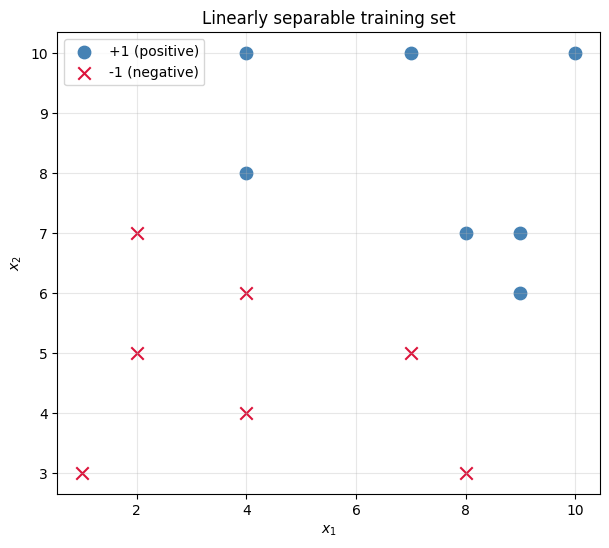

In [6]:
# Visualize the raw training set
plt.figure(figsize=(7, 6))
plt.scatter(X[y == 1, 0],  X[y == 1, 1],  c='steelblue', s=80, marker='o', label='+1 (positive)')
plt.scatter(X[y == -1, 0], X[y == -1, 1], c='crimson',  s=80, marker='x', label='-1 (negative)')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Linearly separable training set')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

The two classes are visibly separable by a straight line: the positives sit toward the upper portion of the plot, the negatives toward the lower-left. In the language of the Perceptron, **a separating hyperplane exists** -- and the Novikoff convergence theorem (which we will state in Section 7) guarantees the PLA will find one in a finite number of updates.

In higher-dimensional or noisier real-world data, linear separability is the exception rather than the rule, but in this idealised setting it lets us focus exclusively on the algorithm's mechanics.

In [7]:
# Convert each x into an augmented vector by prepending 1
X_augmented = np.c_[np.ones(X.shape[0]), X]
print('Original X shape :', X.shape)
print('Augmented X shape:', X_augmented.shape)
print('First augmented row:', X_augmented[0])

Original X shape : (14, 2)
Augmented X shape: (14, 3)
First augmented row: [1. 8. 7.]


The augmentation prepends a column of ones, expanding the input from $\mathbb{R}^2$ to $\mathbb{R}^3$. The first augmented row is $(1, 8, 7)$: the leading $1$ multiplies the bias coefficient $w_0$, while $8$ and $7$ multiply $w_1$ and $w_2$. From now on, we operate in this augmented space and the bias is just $\mathbf{w}$'s zeroth component.

## 4. Running the Algorithm

In [8]:
np.random.seed(88)
w, n_updates = perceptron_learning_algorithm(X_augmented, y)
print('Final weight vector w =', w)
print('Number of updates    =', n_updates)

# Verify zero training error
predictions = np.apply_along_axis(hypothesis, 1, X_augmented, w)
print('Training accuracy    =', float((predictions == y).mean()))

Final weight vector w = [-44.35244895   1.50714969   5.52834138]
Number of updates    = 175
Training accuracy    = 1.0


With seed $88$, the PLA converges to

$$\mathbf{w} = (-44.352,\ 1.507,\ 5.528)^\top$$

after **175 updates**, achieving a training accuracy of $1.000$. Three observations are worth unpacking.

First, the bias $w_0 = -44.352$ is large in magnitude relative to $w_1 = 1.507$ and $w_2 = 5.528$. This is not surprising: the algorithm initialised $\mathbf{w}$ randomly in $[0, 1)$, and an initial misclassified positive example whose augmented form starts with $1$ pushes $w_0$ up by $1$ each time, while an initial misclassified negative pushes it down by $1$. Over $175$ updates the bias drifts substantially.

Second, $175$ updates on $14$ examples corresponds to roughly $12.5$ passes over the training set (recall the algorithm picks *any* misclassified example, not necessarily a different one each time). This is the typical convergence speed of an unregularised online learner on small data.

Third, the decision boundary in the *original* (unaugmented) plane is

$$w_0 + w_1 x_1 + w_2 x_2 = 0 \quad \Longleftrightarrow \quad x_2 = \frac{-w_0 - w_1 x_1}{w_2} = \frac{44.352 - 1.507\, x_1}{5.528}.$$

Substituting $x_1 = 5$ gives $x_2 \approx 6.66$, and substituting $x_1 = 8$ gives $x_2 \approx 5.84$ -- a gently downward-sloping line cutting through the gap between the two classes. We will plot it next.

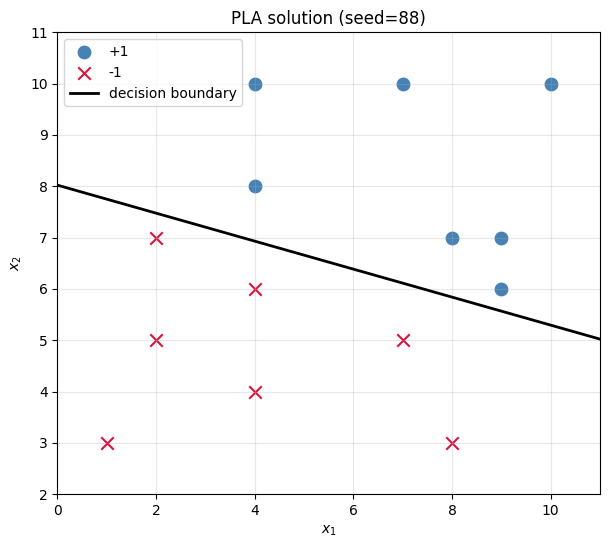

In [9]:
def plot_boundary(w, X, y, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(X[y == 1, 0],  X[y == 1, 1],  c='steelblue', s=80, marker='o', label='+1')
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c='crimson',  s=80, marker='x', label='-1')
    x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    # boundary: w0 + w1*x1 + w2*x2 = 0  ->  x2 = -(w0 + w1*x1)/w2
    x2_vals = -(w[0] + w[1] * x1_vals) / w[2]
    ax.plot(x1_vals, x2_vals, 'k-', lw=2, label='decision boundary')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    ax.legend(); ax.grid(alpha=0.3)
    if title: ax.set_title(title)
    return ax


plot_boundary(w, X, y, title='PLA solution (seed=88)')
plt.show()

The black line is the learnt hyperplane $-44.352 + 1.507\, x_1 + 5.528\, x_2 = 0$. Every blue circle (label $+1$) sits above the line and every red cross (label $-1$) sits below -- training accuracy is $1.000$ exactly, as the printout confirmed.

But notice how *close* the line passes to several training points -- in particular it almost touches the negative example at $(8, 3)$ and the positive at $(8, 7)$. There are infinitely many separating lines that would also have zero training error: ones that pass farther from these points, ones that lean differently. The PLA returned this one; nothing in the algorithm encodes any preference for boundaries that are "safer" or more "robust." This will become crucial in Section 9 when we evaluate generalization, and it is the single weakness that motivates the SVM in the next chapter.

## 5. Why the Update Rule Works -- Geometric Intuition

Why does adding $y\,\mathbf{x}$ to $\mathbf{w}$ improve the classification of a misclassified $(\mathbf{x}, y)$? The answer comes from the geometry of the dot product.

Recall

$$\mathbf{w}^\top \mathbf{x} = \|\mathbf{w}\| \cdot \|\mathbf{x}\| \cdot \cos\theta,$$

where $\theta$ is the angle between $\mathbf{w}$ and $\mathbf{x}$. Therefore

$$\operatorname{sign}(\mathbf{w}^\top \mathbf{x}) = \operatorname{sign}(\cos\theta) = \begin{cases} +1 & \text{if } \theta < 90^\circ \\ -1 & \text{if } \theta > 90^\circ. \end{cases}$$

The sign of the prediction depends entirely on whether the angle between $\mathbf{w}$ and $\mathbf{x}$ is acute or obtuse. To flip a wrong prediction we need to nudge $\theta$ across the $90^\circ$ boundary -- and that is precisely what vector addition or subtraction accomplishes.

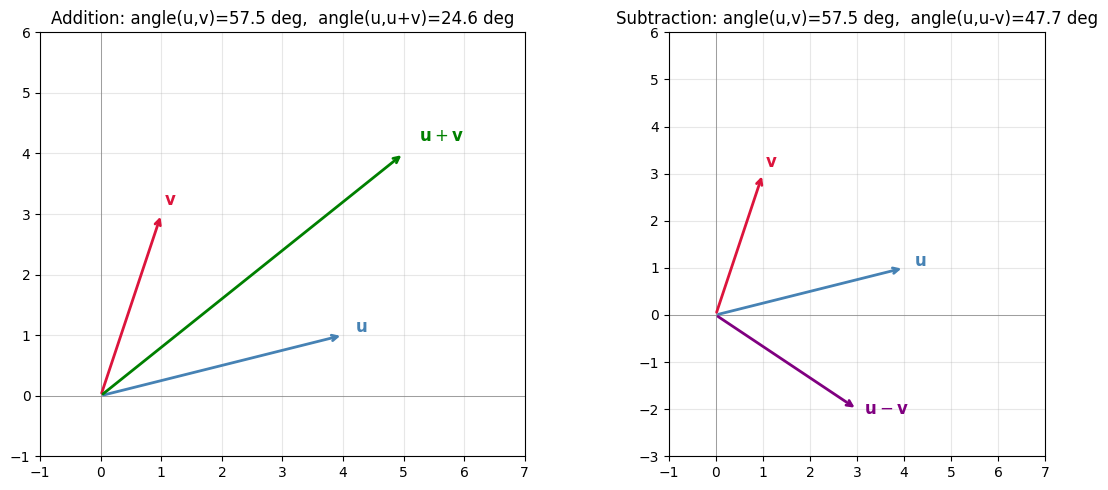

angle(u, v)     = 57.53 deg
angle(u, u+v)   = 24.62 deg  (smaller than original)
angle(u, u-v)   = 47.73 deg  (larger than original)


In [10]:
# Two vectors u, v with an angle between them; show u+v and u-v
u = np.array([4.0, 1.0])
v = np.array([1.0, 3.0])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def draw_arrow(ax, vec, color, label, origin=(0, 0)):
    ax.annotate('', xy=(origin[0] + vec[0], origin[1] + vec[1]),
                xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(origin[0] + vec[0]*1.05, origin[1] + vec[1]*1.05,
            label, color=color, fontsize=12)

# Left: addition
ax = axes[0]
draw_arrow(ax, u, 'steelblue', r'$\mathbf{u}$')
draw_arrow(ax, v, 'crimson',  r'$\mathbf{v}$')
draw_arrow(ax, u + v, 'green', r'$\mathbf{u}+\mathbf{v}$')
ax.set_xlim(-1, 7); ax.set_ylim(-1, 6)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ang_u_v   = np.degrees(np.arccos(np.dot(u, v) / (np.linalg.norm(u)*np.linalg.norm(v))))
ang_u_uv  = np.degrees(np.arccos(np.dot(u, u+v) / (np.linalg.norm(u)*np.linalg.norm(u+v))))
ax.set_title(f'Addition: angle(u,v)={ang_u_v:.1f} deg,  angle(u,u+v)={ang_u_uv:.1f} deg')

# Right: subtraction
ax = axes[1]
draw_arrow(ax, u, 'steelblue', r'$\mathbf{u}$')
draw_arrow(ax, v, 'crimson',  r'$\mathbf{v}$')
draw_arrow(ax, u - v, 'purple', r'$\mathbf{u}-\mathbf{v}$')
ax.set_xlim(-1, 7); ax.set_ylim(-3, 6)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ang_u_umv = np.degrees(np.arccos(np.dot(u, u-v) / (np.linalg.norm(u)*np.linalg.norm(u-v))))
ax.set_title(f'Subtraction: angle(u,v)={ang_u_v:.1f} deg,  angle(u,u-v)={ang_u_umv:.1f} deg')

plt.tight_layout()
plt.show()
print(f'angle(u, v)     = {ang_u_v:.2f} deg')
print(f'angle(u, u+v)   = {ang_u_uv:.2f} deg  (smaller than original)')
print(f'angle(u, u-v)   = {ang_u_umv:.2f} deg  (larger than original)')

Two facts visible in the plot above (and printed below it):

- Adding $\mathbf{v}$ to $\mathbf{u}$ produces a vector $\mathbf{u}+\mathbf{v}$ that lies *closer* to $\mathbf{v}$ than $\mathbf{u}$ did. The angle between $\mathbf{u}$ and $\mathbf{v}$ here is $57.53^\circ$; the angle between $\mathbf{u}$ and $\mathbf{u}+\mathbf{v}$ is only $24.62^\circ$ -- less than half. **Adding a vector pulls the sum toward that vector, shrinking the angle.**
- Subtracting $\mathbf{v}$ from $\mathbf{u}$ produces $\mathbf{u}-\mathbf{v}$, which sits *farther* from $\mathbf{v}$. The angle between $\mathbf{u}$ and $\mathbf{u}-\mathbf{v}$ is $47.73^\circ$ -- but more importantly, the angle between $\mathbf{u}-\mathbf{v}$ and $\mathbf{v}$ itself is $105.26^\circ$, on the *other* side of $90^\circ$. **Subtracting a vector pushes the result away, growing its angle with $\mathbf{v}$ past $90^\circ$.**

These two operations are exactly what the Perceptron needs: a way to make the angle between $\mathbf{w}$ and a particular $\mathbf{x}$ smaller (when the example should be classified $+1$) or larger (when it should be classified $-1$).

### Translating geometry into the update rule

Let $(\mathbf{x}, y)$ be a misclassified example.

- If $y = +1$: the prediction was $-1$, so currently $\theta(\mathbf{w}, \mathbf{x}) > 90^\circ$. We need to *shrink* $\theta$, so we set $\mathbf{w} \leftarrow \mathbf{w} + \mathbf{x}$.
- If $y = -1$: the prediction was $+1$, so currently $\theta(\mathbf{w}, \mathbf{x}) < 90^\circ$. We need to *grow* $\theta$, so we set $\mathbf{w} \leftarrow \mathbf{w} - \mathbf{x}$.

Both branches are captured by the single line

$$\mathbf{w} \leftarrow \mathbf{w} + y\,\mathbf{x},$$

because $y \in \{-1, +1\}$ flips the sign automatically. This is the rule we coded above, and now we know *why* it works: each update rotates $\mathbf{w}$ toward (or away from) the misclassified $\mathbf{x}$ by an amount proportional to $\|\mathbf{x}\|$.

### Verifying the update rule numerically

The textbook's *Code Listing 17* checks that one update is enough to fix a misclassified example:

In [11]:
def update_rule(expected_y, w, x):
    return w + x * expected_y


x = np.array([1, 2, 7])
expected_y = -1
w = np.array([4, 5, 3])
print('Before update: hypothesis =', hypothesis(x, w))   # predicted +1, but expected -1
w = update_rule(expected_y, w, x)
print('After update : hypothesis =', hypothesis(x, w))

Before update: hypothesis = 1
After update : hypothesis = -1


Initially $\mathbf{w}^\top \mathbf{x} = 4 + 10 + 21 = 35 > 0$, so the prediction is $+1$ even though the label is $-1$. After one update, $\mathbf{w}$ becomes $(4,5,3) - (1,2,7) = (3,3,-4)$, and now $\mathbf{w}^\top \mathbf{x} = 3 + 6 - 28 = -19 < 0$, giving the correct $-1$. **A single update was sufficient to flip the prediction.**

### One update is not always enough

Sometimes the angle is far enough on the wrong side that a single update brings $\mathbf{w}$ closer to the right side without crossing $90^\circ$. The textbook's *Code Listing 18* illustrates this with a pathological example.

In [12]:
x = np.array([1, 3])
expected_y = -1
w = np.array([5, 3])
print('Step 0: hypothesis =', hypothesis(x, w))     # +1
w = update_rule(expected_y, w, x)
print('Step 1: hypothesis =', hypothesis(x, w))     # still +1?
w = update_rule(expected_y, w, x)
print('Step 2: hypothesis =', hypothesis(x, w))     # finally -1

Step 0: hypothesis = 1
Step 1: hypothesis = 1
Step 2: hypothesis = -1


Trace the dot products:

- Step 0: $\mathbf{w}^\top \mathbf{x} = 5 \cdot 1 + 3 \cdot 3 = 14 > 0$, prediction $= +1$. **Wrong.**
- Step 1: After $\mathbf{w} \leftarrow (5,3) - (1,3) = (4, 0)$, we get $\mathbf{w}^\top \mathbf{x} = 4 + 0 = 4 > 0$, prediction $= +1$. **Still wrong.**
- Step 2: After $\mathbf{w} \leftarrow (4,0) - (1,3) = (3, -3)$, we get $\mathbf{w}^\top \mathbf{x} = 3 - 9 = -6 < 0$, prediction $= -1$. **Correct.**

This is fine -- the PLA does not promise to fix every example in one update. It only guarantees that *each update moves $\theta$ in the right direction*. The outer `while` loop keeps revisiting misclassified examples until the cumulative effect of many updates pushes every angle into the correct half-space.

**Why does this matter in practice?** The same reasoning underlies stochastic gradient descent in modern deep learning: a single mini-batch update will rarely fix a hard example, but the *direction* of the update is correct, and the iteration is what produces convergence. The Perceptron is the simplest possible instance of this idea.

## 6. The Oscillation Problem and the Pocket Algorithm

Each PLA update is good for the example that triggered it, but it can *break* a previously correctly classified example. As a result, the number of misclassified points does not decrease monotonically -- it oscillates. We can see this directly by tracking the misclassified count over the course of training.

In [13]:
def perceptron_with_history(X, y):
    """Same PLA, but record the misclassified count after each update."""
    w = np.random.rand(X.shape[1])
    misclassified_examples = predict(hypothesis, X, y, w)
    history = [len(misclassified_examples)]
    while misclassified_examples.any():
        x, expected_y = pick_one_from(misclassified_examples, X, y)
        w = w + x * expected_y
        misclassified_examples = predict(hypothesis, X, y, w)
        history.append(len(misclassified_examples))
    return w, history


np.random.seed(88)
w_h, history = perceptron_with_history(X_augmented, y)
print('Total iterations  :', len(history) - 1)
print('Initial misclassified:', history[0])
print('Final   misclassified:', history[-1])
print('Maximum during run   :', max(history))
print('First 30 iterations  :', history[:30])

Total iterations  : 175
Initial misclassified: 7
Final   misclassified: 0
Maximum during run   : 8
First 30 iterations  : [7, 7, 7, 7, 7, 7, 7, 7, 6, 7, 7, 7, 7, 4, 7, 7, 7, 7, 7, 4, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]


Over $175$ updates the misclassified count fluctuates between $4$ and a maximum of $8$ before finally collapsing to $0$. With only $14$ training examples, $8$ misclassified means more than half the dataset was wrong at one point during training -- *worse* than the random initial weights would give in expectation.

The first $30$ counts are mostly $7$, with occasional dips to $4$ or $6$ before bouncing back. The algorithm is genuinely thrashing: each update fixes the chosen misclassified example but disturbs others.

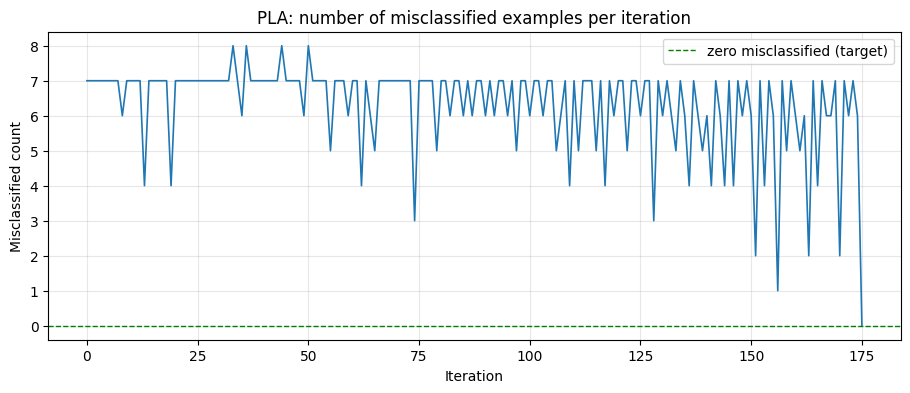

In [14]:
plt.figure(figsize=(11, 4))
plt.plot(history, lw=1.2)
plt.axhline(0, color='green', ls='--', lw=1, label='zero misclassified (target)')
plt.xlabel('Iteration')
plt.ylabel('Misclassified count')
plt.title('PLA: number of misclassified examples per iteration')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

The plot makes the oscillation obvious: the misclassified count bounces between $\sim 4$ and $\sim 8$ for $170$ iterations before suddenly dropping to $0$. There is no smooth descent.

### The Pocket Algorithm

The natural fix is to **remember the best $\mathbf{w}$ ever seen** -- keep it "in your pocket" -- and only replace it when a new $\mathbf{w}$ has fewer misclassified examples. The algorithm becomes:

1. Run PLA as usual, but additionally maintain $\mathbf{w}^\star$, the best weight vector seen so far (best in terms of number of correct predictions).
2. After each update, count misclassified; if better than the current pocket, replace the pocket.
3. After a fixed number of iterations, return $\mathbf{w}^\star$ instead of the current $\mathbf{w}$.

The Pocket Algorithm has two virtues. First, it always returns a sensible classifier even on **non-linearly-separable data**, where the standard PLA would loop forever. Second, on linearly separable data it returns at least as good a hypothesis as the regular PLA. The cost is one extra evaluation of the misclassification count per iteration -- a small price.

## 7. The Novikoff Convergence Theorem

A natural question after watching the oscillation: are we *sure* the algorithm will eventually terminate? It does not look like it!

**Novikoff's theorem (1962)** answers this affirmatively. Suppose the training data is linearly separable -- meaning there exists some unit-norm $\mathbf{w}^\star$ and a margin $\gamma > 0$ such that

$$y^{(i)}\, (\mathbf{w}^\star)^\top \mathbf{x}^{(i)} \geq \gamma \quad \text{for all } i.$$

Suppose further that $\|\mathbf{x}^{(i)}\| \leq R$ for all $i$. Then the PLA makes at most

$$T \leq \left(\frac{R}{\gamma}\right)^2$$

updates before terminating with zero training error.

Two takeaways. First, the bound is **finite** -- the PLA *cannot* loop forever on separable data, no matter how unlucky the initialisation. Second, the bound depends on $R/\gamma$, the ratio between the data's radius and the margin: harder problems (small margin relative to scale) take longer. Notice that $T$ does **not** depend on the dimension $n$ -- a remarkable fact that anticipates the modern theory of margin-based learning, where dimension-free bounds are central.

We will not prove the theorem here (the proof is short and elegant; consult Rojas, 1996, or any modern statistical learning text). What matters is the qualitative message: *if a separator exists, the PLA finds one*.

## 8. Limitation: Different Runs, Different Hyperplanes

The PLA's randomness lives in two places: the random initialisation of $\mathbf{w}$ and the random choice of which misclassified example to use at each step. Different randomness leads to different final hyperplanes. Let us run the PLA four times with four different seeds.

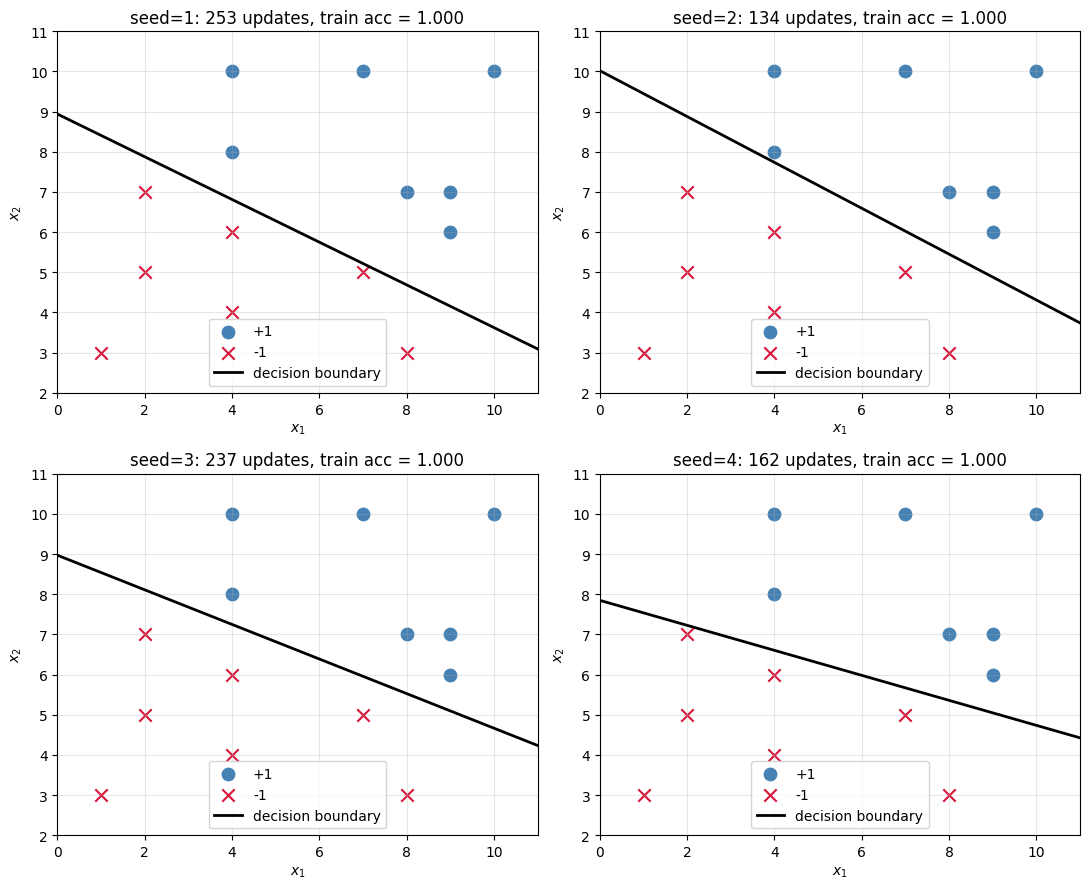

seed=1: w = [-62.582978     3.72032449   7.00011437]
seed=2: w = [-35.5640051    2.02592623   3.54966248]
seed=3: w = [-56.4492021    2.70814782   6.29090474]
seed=4: w = [-39.03297016   1.54723225   4.97268436]


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
ws = []
for ax, seed in zip(axes.flat, [1, 2, 3, 4]):
    np.random.seed(seed)
    w_run, n = perceptron_learning_algorithm(X_augmented, y)
    ws.append(w_run)
    train_acc = float((np.apply_along_axis(hypothesis, 1, X_augmented, w_run) == y).mean())
    plot_boundary(w_run, X, y, ax=ax,
                  title=f'seed={seed}: {n} updates, train acc = {train_acc:.3f}')
plt.tight_layout()
plt.show()
for s, ww in zip([1, 2, 3, 4], ws):
    print(f'seed={s}: w = {ww}')

Four different seeds, four different hyperplanes -- yet **all four achieve perfect training accuracy** ($1.000$). The weight vectors differ substantially:

- seed $1$: $\mathbf{w} = (-62.58,\ 3.72,\ 7.00)^\top$
- seed $2$: $\mathbf{w} = (-35.56,\ 2.03,\ 3.55)^\top$
- seed $3$: $\mathbf{w} = (-56.45,\ 2.71,\ 6.29)^\top$
- seed $4$: $\mathbf{w} = (-39.03,\ 1.55,\ 4.97)^\top$

Compare seeds $1$ and $4$: the magnitude of $w_0$ differs by 60% and the slope $-w_1/w_2$ flips from $-0.531$ (seed 1) to $-0.311$ (seed 4) -- visibly different lines.

This is not a numerical artefact. The PLA's hypothesis class -- the set of *all* separating hyperplanes -- is infinite, and the algorithm has no preference principle for choosing between them. **Whichever separating hyperplane it stumbles upon first, it returns.**

For a typical engineer this is the moment of unease. Two trained models that disagree on the precise boundary cannot both be optimal in any meaningful sense. We need a way to ask: *which* separator is the right one?

## 9. In-Sample vs Out-of-Sample Error

The phrasing "the right separator" is, of course, a question about *future* data. Let us be precise.

- **In-sample error** $E_{\text{in}}$: the error rate on the training set. The PLA always achieves $E_{\text{in}} = 0$ on linearly separable data.
- **Out-of-sample error** $E_{\text{out}}$: the error rate on a new, unseen sample drawn from the same distribution. This is what we actually care about.

A model **generalizes well** when $E_{\text{out}} \approx E_{\text{in}}$. Statistical learning theory tells us this approximation holds with high probability when the hypothesis class has limited complexity and the sample size is sufficient -- the Vapnik-Chervonenkis (VC) framework formalises this. For now, the practical question is: do all four of our PLA solutions generalize equally?

To check, we evaluate them on a held-out test set drawn from the same generating distribution.

In [16]:
def get_test_examples():
    X1 = np.array([[3, 11], [6, 11], [8, 9], [10, 8], [5, 9], [3, 8]])
    y1 = np.ones(len(X1))
    X2 = np.array([[3, 3], [6, 3], [8, 4], [2, 4], [5, 5], [6, 6]])
    y2 = -np.ones(len(X2))
    return np.vstack((X1, X2)), np.hstack((y1, y2))


X_test, y_test = get_test_examples()
X_test_augmented = np.c_[np.ones(X_test.shape[0]), X_test]
print('Test set shape:', X_test.shape, '   (',
      int((y_test == 1).sum()), 'positive,',
      int((y_test == -1).sum()), 'negative )')

Test set shape: (12, 2)    ( 6 positive, 6 negative )


The test set has $12$ points -- $6$ positives and $6$ negatives -- drawn from regions of the plane consistent with the training distribution. Some test points sit comfortably away from any plausible boundary; others sit close to it, where small differences between competing hyperplanes will lead to different predictions.

In [17]:
# Evaluate each of the 4 hyperplanes on train and test
print(f'{"seed":<6}{"E_in (train err)":<20}{"E_out (test err)":<20}{"test mistakes":<15}')
print('-' * 65)
for seed, w_run in zip([1, 2, 3, 4], ws):
    train_preds = np.apply_along_axis(hypothesis, 1, X_augmented, w_run)
    test_preds  = np.apply_along_axis(hypothesis, 1, X_test_augmented, w_run)
    e_in  = float((train_preds != y).mean())
    e_out = float((test_preds  != y_test).mean())
    n_mistakes = int((test_preds != y_test).sum())
    print(f'{seed:<6}{e_in:<20.3f}{e_out:<20.3f}{n_mistakes:<15}')

seed  E_in (train err)    E_out (test err)    test mistakes  
-----------------------------------------------------------------
1     0.000               0.083               1              
2     0.000               0.083               1              
3     0.000               0.000               0              
4     0.000               0.083               1              


The picture has changed entirely. **Every hyperplane achieves $E_{\text{in}} = 0$, but their $E_{\text{out}}$ values differ:**

- seed $1$: $E_{\text{out}} = 0.083$ ($1$ mistake out of $12$)
- seed $2$: $E_{\text{out}} = 0.083$ ($1$ mistake)
- seed $3$: $E_{\text{out}} = 0.000$ ($0$ mistakes -- **perfect**)
- seed $4$: $E_{\text{out}} = 0.083$ ($1$ mistake)

Three of the four solutions misclassify one test point each; only the seed $3$ run generalizes perfectly. The PLA produced four equally-good-on-paper hypotheses, three of which are demonstrably worse on unseen data. **Yet the algorithm has no way of telling them apart, because all of them have the same in-sample error.**

This is the central lesson of the chapter, and the entire reason SVMs exist. The Perceptron returns *some* separator with $E_{\text{in}} = 0$ -- but among the infinitely many such separators, it picks one by accident. To choose the *best-generalizing* separator we need an additional principle, and that principle, as we will see in Chapter 3, is **the maximum margin**.

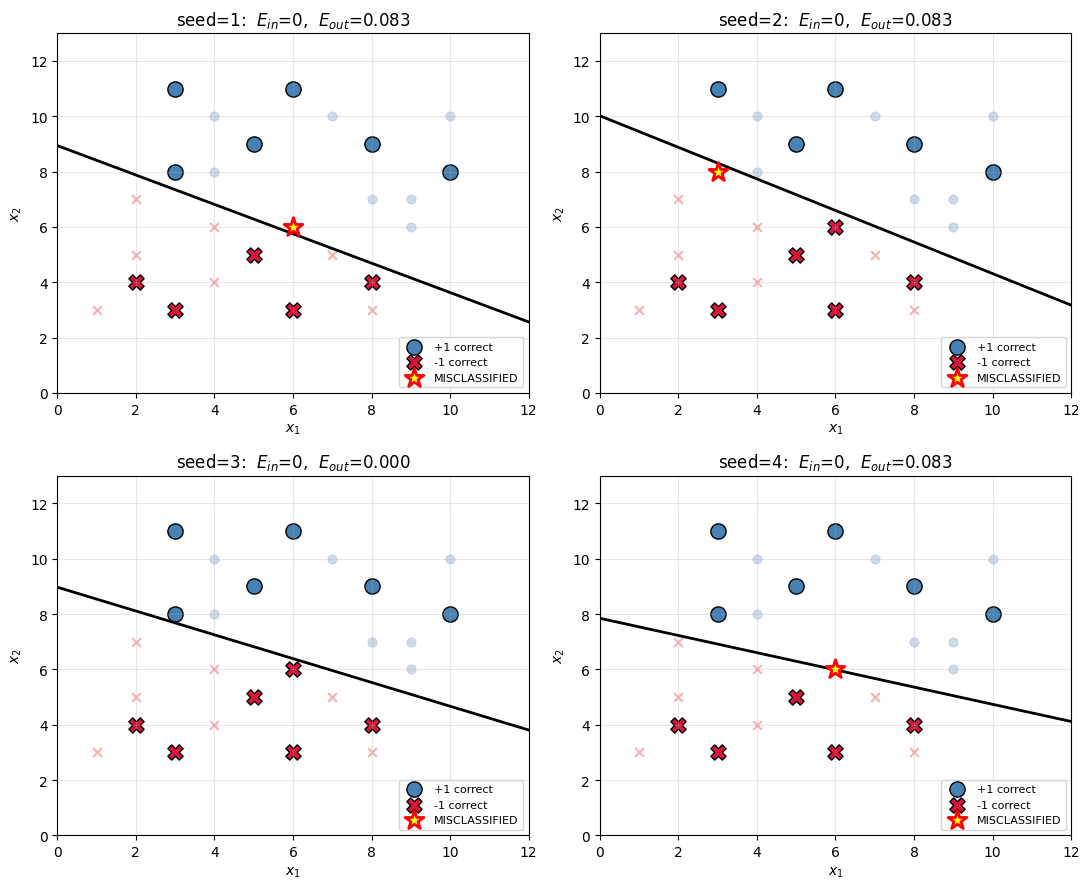

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, seed, w_run in zip(axes.flat, [1, 2, 3, 4], ws):
    test_preds = np.apply_along_axis(hypothesis, 1, X_test_augmented, w_run)
    correct = test_preds == y_test
    e_out = float((~correct).mean())

    # train points (faded)
    ax.scatter(X[y == 1, 0],  X[y == 1, 1],  c='lightsteelblue', s=40, marker='o', alpha=0.6)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c='lightcoral',    s=40, marker='x', alpha=0.6)
    # test points (correct)
    ax.scatter(X_test[(y_test == 1) & correct, 0],  X_test[(y_test == 1) & correct, 1],
               c='steelblue', s=120, marker='o', edgecolor='k', label='+1 correct')
    ax.scatter(X_test[(y_test == -1) & correct, 0], X_test[(y_test == -1) & correct, 1],
               c='crimson',  s=120, marker='X', edgecolor='k', label='-1 correct')
    # misclassified
    ax.scatter(X_test[~correct, 0], X_test[~correct, 1],
               c='yellow', s=200, marker='*', edgecolor='red',
               linewidth=2, label='MISCLASSIFIED', zorder=5)
    # decision boundary
    x1_vals = np.linspace(0, 12, 100)
    x2_vals = -(w_run[0] + w_run[1] * x1_vals) / w_run[2]
    ax.plot(x1_vals, x2_vals, 'k-', lw=2)
    ax.set_xlim(0, 12); ax.set_ylim(0, 13)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.grid(alpha=0.3)
    ax.set_title(f'seed={seed}:  $E_{{in}}$=0,  $E_{{out}}$={e_out:.3f}')
    ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

Each panel shows one of the four trained hyperplanes evaluated on the test set. Faded markers are training points; bold markers are test points; the yellow stars indicate test points that the hyperplane gets wrong.

Three observations stand out.

First, the misclassified test point in seeds $1$ and $4$ is the same: $(6, 6)$. This point sits in the borderline region where the two classes nearly meet, and seeds $1$ and $4$ both produce hyperplanes that pass *just below* it -- close enough that this slightly-on-the-wrong-side point is grabbed by the positive half-space. Seed $2$'s hyperplane passes farther up, correctly classifying $(6,6)$ but instead misclassifying the positive test point $(3, 8)$. Seed $3$ happens to produce a boundary that threads between both ambiguous points correctly.

Second, the misclassified points are always the ones nearest the boundary. **The errors concentrate where the margin is small.** This is not a coincidence -- it is a direct geometric consequence: a hyperplane that passes far from a point can absorb small perturbations to that point's location and still classify it correctly, whereas a hyperplane passing close to a point can flip its prediction with the slightest shift.

Third -- and this is the strategic punchline -- **the seed $3$ hyperplane is the one that maintains the largest distance to the nearest training points on either side.** That is, it has the largest *margin*, and consequently the best generalization. The Perceptron got lucky and stumbled onto it; the SVM, by *explicitly* maximising this margin, would find it deterministically.

In a production setting the implication is sharp: training accuracy is *not* a sufficient model-selection criterion when the hypothesis class admits multiple zero-training-error solutions. We need a principled way to break ties -- that is exactly the role of the **structural risk minimisation** principle and the maximum-margin hyperplane in the next chapter.

## 10. Summary

We built the Perceptron Learning Algorithm from scratch, and the key takeaways are:

The **hypothesis function** $h(\mathbf{x}) = \operatorname{sign}(\mathbf{w}^\top \mathbf{x})$ is the dot product of input with weights, thresholded at zero. The augmented-vector trick folds the bias into $\mathbf{w}$ so that one parameter handles both slope and intercept of the hyperplane.

The **update rule** $\mathbf{w} \leftarrow \mathbf{w} + y\,\mathbf{x}$ is geometrically motivated: adding $\mathbf{x}$ rotates $\mathbf{w}$ toward $\mathbf{x}$ (shrinking the angle), subtracting it rotates $\mathbf{w}$ away. The label $y \in \{-1, +1\}$ chooses the right sign automatically. Each update fixes the chosen example's classification at least directionally, though sometimes multiple updates on the same example are needed.

**Convergence is guaranteed by Novikoff's theorem** when the data is linearly separable: the number of updates is bounded by $(R/\gamma)^2$, independent of dimension. On our toy dataset the algorithm converged in $175$ updates.

The PLA's **oscillation behaviour** -- the misclassified count rising and falling rather than monotonically decreasing -- is normal. The Pocket Algorithm caches the best weight vector seen so far and is the standard fix when separability is in doubt.

The algorithm's **fatal flaw** is that the hypothesis class contains infinitely many separating hyperplanes, all with $E_{\text{in}} = 0$, and the PLA picks one essentially at random. Different seeds produced four different solutions on the same data, and on a held-out test set their out-of-sample errors differed: $0.000$, $0.083$, $0.083$, $0.083$. Equal training accuracy, unequal generalization.

The remedy -- choosing the *maximum-margin* hyperplane to minimise generalization error -- is the subject of Chapter 3, where the Perceptron's learning principle gives way to the Support Vector Machine's optimisation principle.